# генерация

In [ ]:
# def gen(N, x_min, x_max, y_min, y_max, fi1=0, fi2=0, fi3=0, strait_ratio=0.5) #strait_ratio = (0,1) направление прямо или нет
# #float разделить значения с округлением


# def gen_shift( data,  shift = 0.01, y2):
#     data[y2]= data[y2] + shift
#     return data



In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def gen(N, x_min=0, x_max=10, y_min=0, y_max=10, fi1=0, fi2=0, fi3=0, straight_ratio=0.5, rand_seed=40, decimals=None):

    """
    Генерирует данные в формате [x1, y1, x2, y2, x3, y3] для N точек.
    x_min, x_max, y_min, y_max - пределы значений
    straight_ratio определяет процент прямых линий
    rand_seed задаёт сид для локального генератора случайных чисел
    decimals задаёт округление значений до указанного знака

    """

    rng = np.random.default_rng(rand_seed)

    N_straight = int(N * straight_ratio)
    N_avg = N - N_straight

    # прямые линии
    x_strait = rng.uniform(x_min, x_max, N_straight)
    y_strait = rng.uniform(y_min, y_max, N_straight)
    strait_data = np.column_stack([x_strait, y_strait, x_strait, y_strait, x_strait, y_strait])

    # линии под углом
    x1 = rng.uniform(x_min, x_max, N_avg)
    y1 = rng.uniform(y_min, y_max, N_avg)
    x3 = rng.uniform(x_min, x_max, N_avg)
    y3 = rng.uniform(y_min, y_max, N_avg)

    x2 = (x1 + x3) / 2
    y2 = (y1 + y3) / 2
    avg_data = np.column_stack([x1, y1, x2, y2, x3, y3])

    # Объединение
    if N_straight == 0:
        data = avg_data
    elif N_avg == 0:
        data = strait_data
    else:
        data = np.vstack([strait_data, avg_data])

    # Округление
    if decimals is not None:
        data = np.round(data, decimals=decimals)

    return data


def gen_shift(data, shift=0.01, loc=3):
    """создаёт сдвиг указанного размера на указанной позиции"""
    data = data.copy()
    data[:, loc] += shift
    return data


def plot_dist(data, bins=30, figsize=(12, 4)):
    y1, y2, y3 = data[:, 1], data[:, 3], data[:, 5]

    fig, axs = plt.subplots(1, 3, figsize=figsize, sharey=True)
    colors = ['skyblue', 'lightgreen', 'salmon']
    labels = ['y1', 'y2', 'y3']

    for ax, y, color, label in zip(axs, [y1, y2, y3], colors, labels):
        ax.hist(y, bins=bins, color=color, edgecolor='black', alpha=0.8)
        ax.set_xlabel(label)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.set_title(f'Распределение {label}')

    plt.tight_layout()
    plt.show()

In [ ]:
np.set_printoptions(precision=8, suppress=True, floatmode='fixed')

In [ ]:
data = gen(10000, 0, 10, 0, 10, straight_ratio=1, rand_seed=42, decimals=8)
print("До сдвига:\n", data)

data_shifted = gen_shift(data, shift=0.1, loc=3)
print("\nПосле сдвига:\n", data_shifted)

До сдвига:
 [[7.73956049 7.20728387 7.73956049 7.20728387 7.73956049 7.20728387]
 [4.38878440 7.11237761 4.38878440 7.11237761 4.38878440 7.11237761]
 [8.58597920 2.02695031 8.58597920 2.02695031 8.58597920 2.02695031]
 ...
 [1.65346968 8.47131068 1.65346968 8.47131068 1.65346968 8.47131068]
 [3.73410398 6.70803244 3.73410398 6.70803244 3.73410398 6.70803244]
 [4.80907773 1.41260045 4.80907773 1.41260045 4.80907773 1.41260045]]

После сдвига:
 [[7.73956049 7.20728387 7.73956049 7.30728387 7.73956049 7.20728387]
 [4.38878440 7.11237761 4.38878440 7.21237761 4.38878440 7.11237761]
 [8.58597920 2.02695031 8.58597920 2.12695031 8.58597920 2.02695031]
 ...
 [1.65346968 8.47131068 1.65346968 8.57131068 1.65346968 8.47131068]
 [3.73410398 6.70803244 3.73410398 6.80803244 3.73410398 6.70803244]
 [4.80907773 1.41260045 4.80907773 1.51260045 4.80907773 1.41260045]]


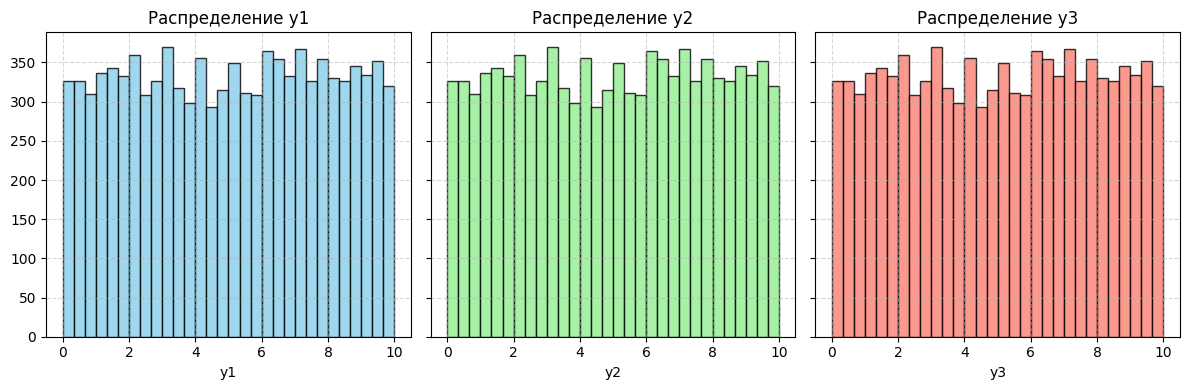

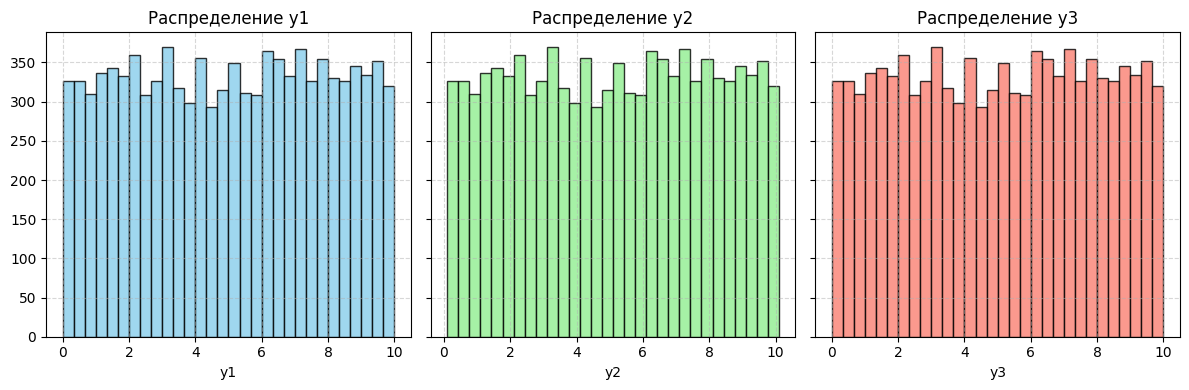

In [ ]:
plot_dist(data)
plot_dist(data_shifted)

In [ ]:
data2 = gen(10000, 0, 10, 0, 10, straight_ratio=0.5, rand_seed=28, decimals=8)
print("До сдвига:\n", data2)

data_shifted_2 = gen_shift(data2.copy(), shift=2, loc=3)
print("\nПосле сдвига:\n", data_shifted_2)

До сдвига:
 [[8.51833936 4.36194842 8.51833936 4.36194842 8.51833936 4.36194842]
 [8.84892954 3.84866468 8.84892954 3.84866468 8.84892954 3.84866468]
 [7.65708527 1.30158475 7.65708527 1.30158475 7.65708527 1.30158475]
 ...
 [7.75785131 7.96953990 8.56783915 4.83547700 9.37782698 1.70141410]
 [5.60198462 8.51752838 3.92379126 7.60244717 2.24559791 6.68736596]
 [6.28798981 5.99425087 5.75923640 5.24345548 5.23048298 4.49266008]]

После сдвига:
 [[8.51833936 4.36194842 8.51833936 6.36194842 8.51833936 4.36194842]
 [8.84892954 3.84866468 8.84892954 5.84866468 8.84892954 3.84866468]
 [7.65708527 1.30158475 7.65708527 3.30158475 7.65708527 1.30158475]
 ...
 [7.75785131 7.96953990 8.56783915 6.83547700 9.37782698 1.70141410]
 [5.60198462 8.51752838 3.92379126 9.60244717 2.24559791 6.68736596]
 [6.28798981 5.99425087 5.75923640 7.24345548 5.23048298 4.49266008]]


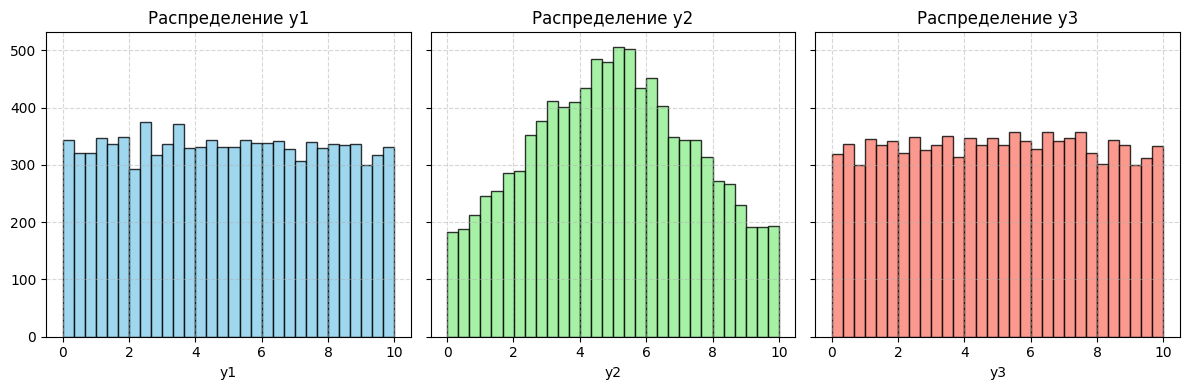

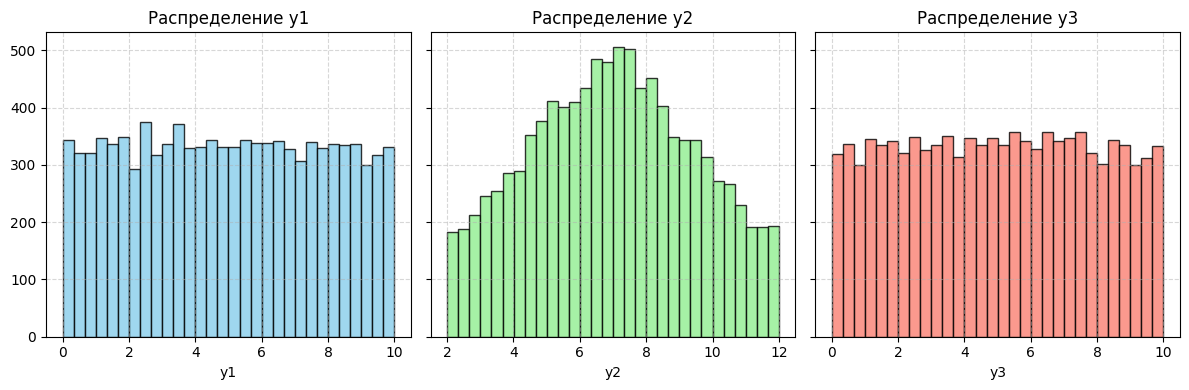

In [ ]:
plot_dist(data2)
plot_dist(data_shifted_2)

# WGAN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import matplotlib.pyplot as plt


In [ ]:
real_data = gen(
    N=500000,
    x_min=0, x_max=10,
    y_min=0, y_max=10,
    straight_ratio=0.5,
    rand_seed=1,
    decimals=4
)

shifted_data_0 = gen(
    N=500000,
    x_min=0, x_max=10,
    y_min=0, y_max=10,
    straight_ratio=0.5,
    rand_seed=2,
    decimals=4
)

shifted_data = gen_shift(shifted_data_0, shift=0.01, loc=3)


In [ ]:
real_tensor = torch.tensor(real_data, dtype=torch.float32)
shifted_tensor = torch.tensor(shifted_data, dtype=torch.float32)

batch_size = 4096
real_loader = DataLoader(TensorDataset(real_tensor), batch_size=batch_size, shuffle=True)
shifted_loader = DataLoader(TensorDataset(shifted_tensor), batch_size=batch_size, shuffle=True)


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.shift = nn.Parameter(torch.zeros(6), requires_grad=True)

    def forward(self, x_shifted):
        return x_shifted + self.shift

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(6, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

In [ ]:
def compute_gradient_penalty(discriminator, real_samples, fake_samples, device, lambda_gp=10.0):
    """
    Вычисляет gradient penalty для WGAN-GP.
    Возвращает: (значение штрафа, средняя норма градиента)
    """
    batch_size = real_samples.size(0)

    #Интерполяция (ε ~ U[0, 1])
    epsilon = torch.rand(batch_size, 1, device=device)
    epsilon = epsilon.expand_as(real_samples)

    #Интерполированные сэмплы
    interpolates = (epsilon * real_samples + (1 - epsilon) * fake_samples).requires_grad_(True)

    d_interpolates = discriminator(interpolates)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates, device=device),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]

    gradients = gradients.view(batch_size, -1)
    grad_norm = gradients.norm(2, dim=1)

    gradient_penalty = lambda_gp * ((grad_norm - 1) ** 2).mean()

    return gradient_penalty, grad_norm

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

G = Generator().to(device)
D = Discriminator().to(device)

opt_G = optim.Adam(G.parameters(), lr=5e-6, betas=(0.5, 0.9))
opt_D = optim.Adam(D.parameters(), lr=1e-4, betas=(0.5, 0.9))
# opt_D = optim.RMSprop(D.parameters(), lr=5e-5)

# scheduler_G = optim.lr_scheduler.ExponentialLR(opt_G, gamma=0.98)
# scheduler_D = optim.lr_scheduler.ExponentialLR(opt_D, gamma=0.98)

In [ ]:
epochs = 800

losses_G = []
losses_D = []
gen_weight_norms = []
shift_history = []

n_critic = 10

In [ ]:
ema_shift = 0.0
alpha = 0.995  # можно 0.99–0.999
ema_history = []

In [ ]:
for epoch in range(epochs):

    for (real_batch,), (shifted_batch,) in zip(real_loader, shifted_loader):
        real_batch = real_batch.to(device)
        shifted_batch = shifted_batch.to(device)

        # обучаем D несколько раз
        for _ in range(n_critic):
            opt_D.zero_grad()

            real_pred = D(real_batch)
            fake_data = G(shifted_batch).detach()
            fake_pred = D(fake_data)

            loss_D_wgan = -real_pred.mean() + fake_pred.mean()
            gp, grad_norm = compute_gradient_penalty(D, real_batch, fake_data, device)

            loss_D = loss_D_wgan + gp
            loss_D.backward()
            opt_D.step()

        # обучаем G один раз
        opt_G.zero_grad()
        gen_data = G(shifted_batch)
        pred = D(gen_data)
        loss_G = -pred.mean()
        loss_G.backward()
        opt_G.step()

        # Логирование
        losses_D.append(loss_D.item())
        losses_G.append(loss_G.item())

    shift_history.append(G.shift.detach().cpu().numpy().copy())
    current_shift = G.shift[3].item()
    ema_shift = alpha * ema_shift + (1 - alpha) * current_shift
    ema_history.append(ema_shift)
    print(f"Выученный сдвиг по y2: {G.shift[3].item():.6f}")
    print(f"Epoch {epoch+1}/{epochs} | D: {loss_D.item():.4f} | G: {loss_G.item():.4f}")
    print(f"  ||grad||_2 mean: {grad_norm.mean().item():.4f} | GP: {gp.item():.4f}")
    print(f"EMA shift: {ema_shift:.6f}")

Выученный сдвиг по y2: 0.000035
Epoch 1/800 | D: -0.1853 | G: 4.1394
  ||grad||_2 mean: 1.0068 | GP: 0.0125
EMA shift: 0.000000
Выученный сдвиг по y2: -0.000575
Epoch 2/800 | D: -0.3018 | G: 11.5167
  ||grad||_2 mean: 1.0185 | GP: 0.0091
EMA shift: -0.000003
Выученный сдвиг по y2: -0.001196
Epoch 3/800 | D: -0.1674 | G: -1.1577
  ||grad||_2 mean: 1.0006 | GP: 0.0155
EMA shift: -0.000009
Выученный сдвиг по y2: -0.001802
Epoch 4/800 | D: -0.0840 | G: 0.8481
  ||grad||_2 mean: 1.0011 | GP: 0.0058
EMA shift: -0.000018
Выученный сдвиг по y2: -0.002335
Epoch 5/800 | D: 0.1352 | G: -4.0573
  ||grad||_2 mean: 0.9889 | GP: 0.0076
EMA shift: -0.000029
Выученный сдвиг по y2: -0.002908
Epoch 6/800 | D: -0.1358 | G: 6.5348
  ||grad||_2 mean: 1.0182 | GP: 0.0067
EMA shift: -0.000044
Выученный сдвиг по y2: -0.003521
Epoch 7/800 | D: 0.0398 | G: 7.4430
  ||grad||_2 mean: 1.0059 | GP: 0.0121
EMA shift: -0.000061
Выученный сдвиг по y2: -0.004102
Epoch 8/800 | D: -0.1111 | G: 3.4013
  ||grad||_2 mean: 1.

# bc=4096, N=500000, straight_ratio = 0.5

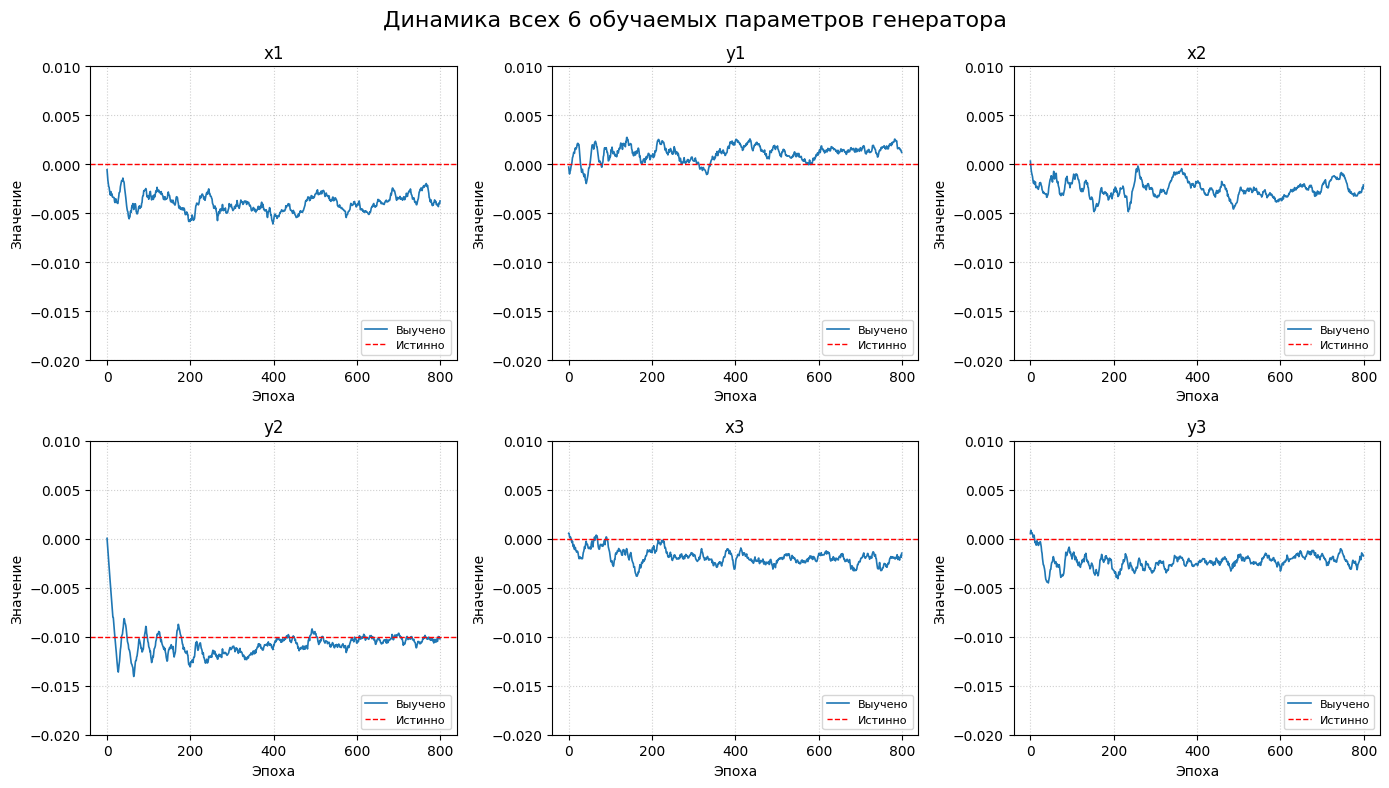

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

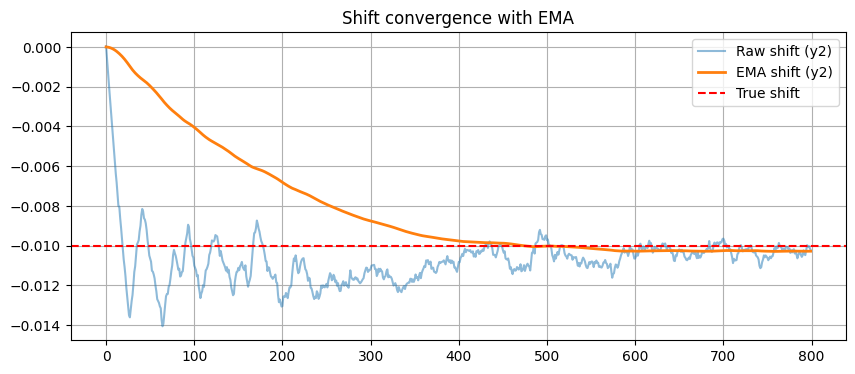

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

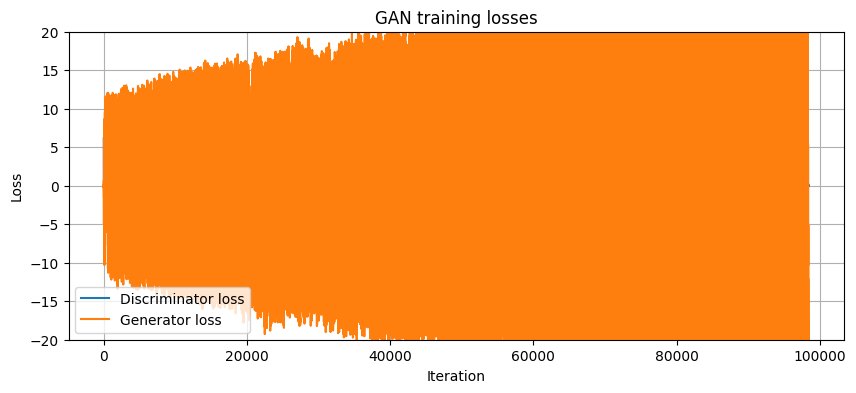

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


# bc = 8192

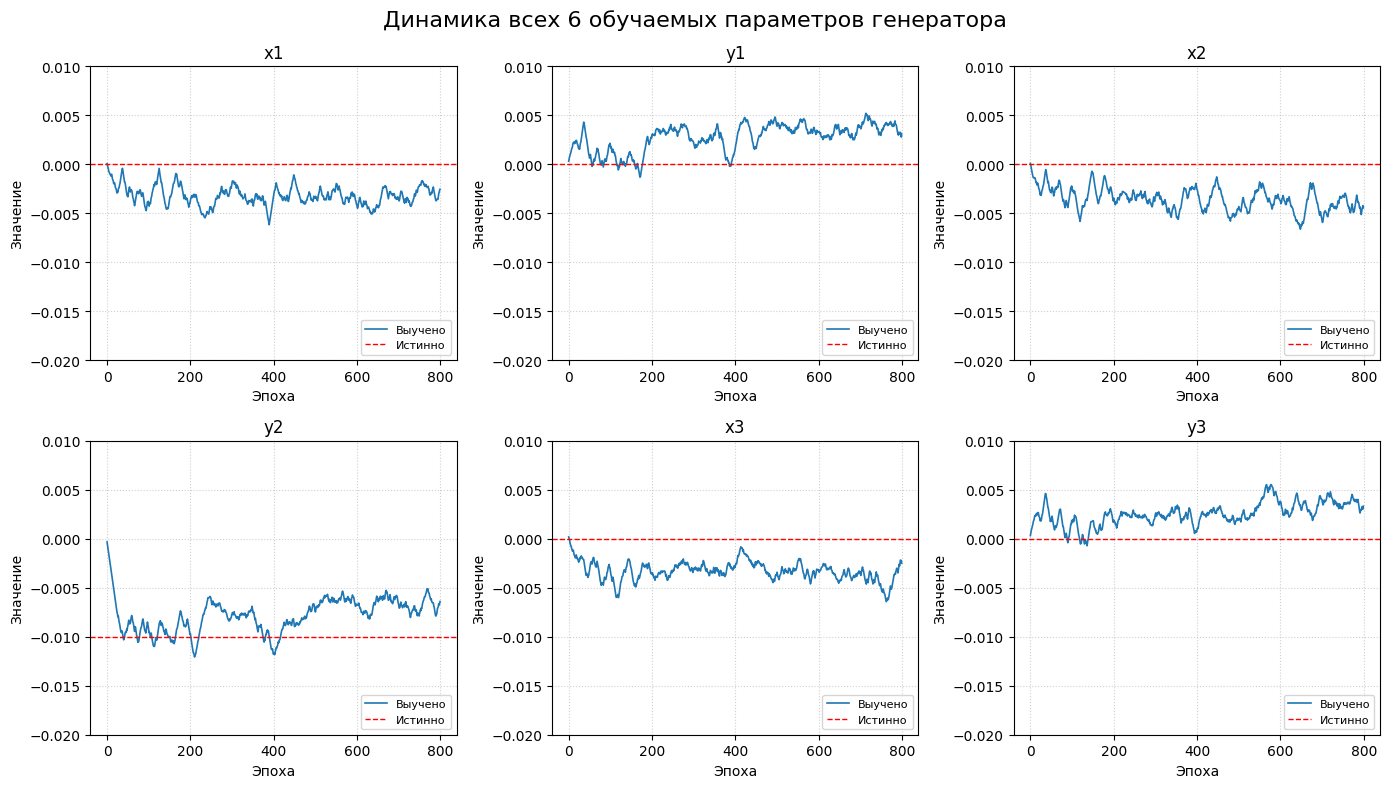

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

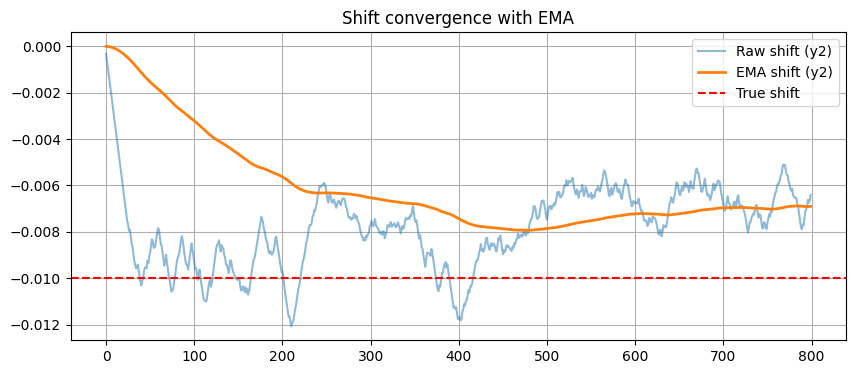

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

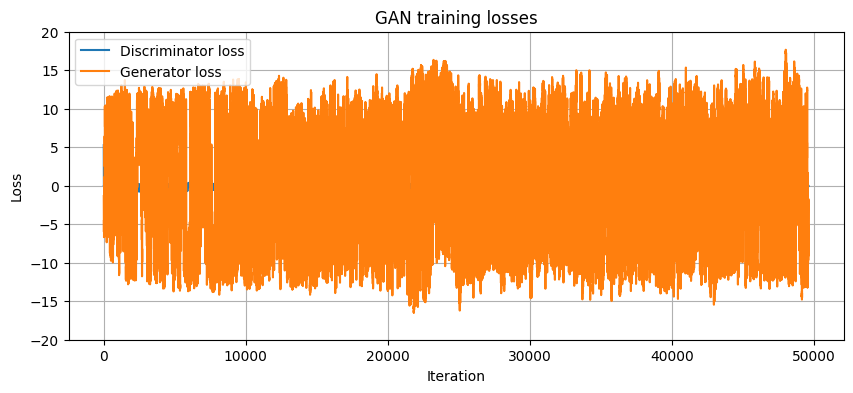

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


# N = 500000, n_critic = 10

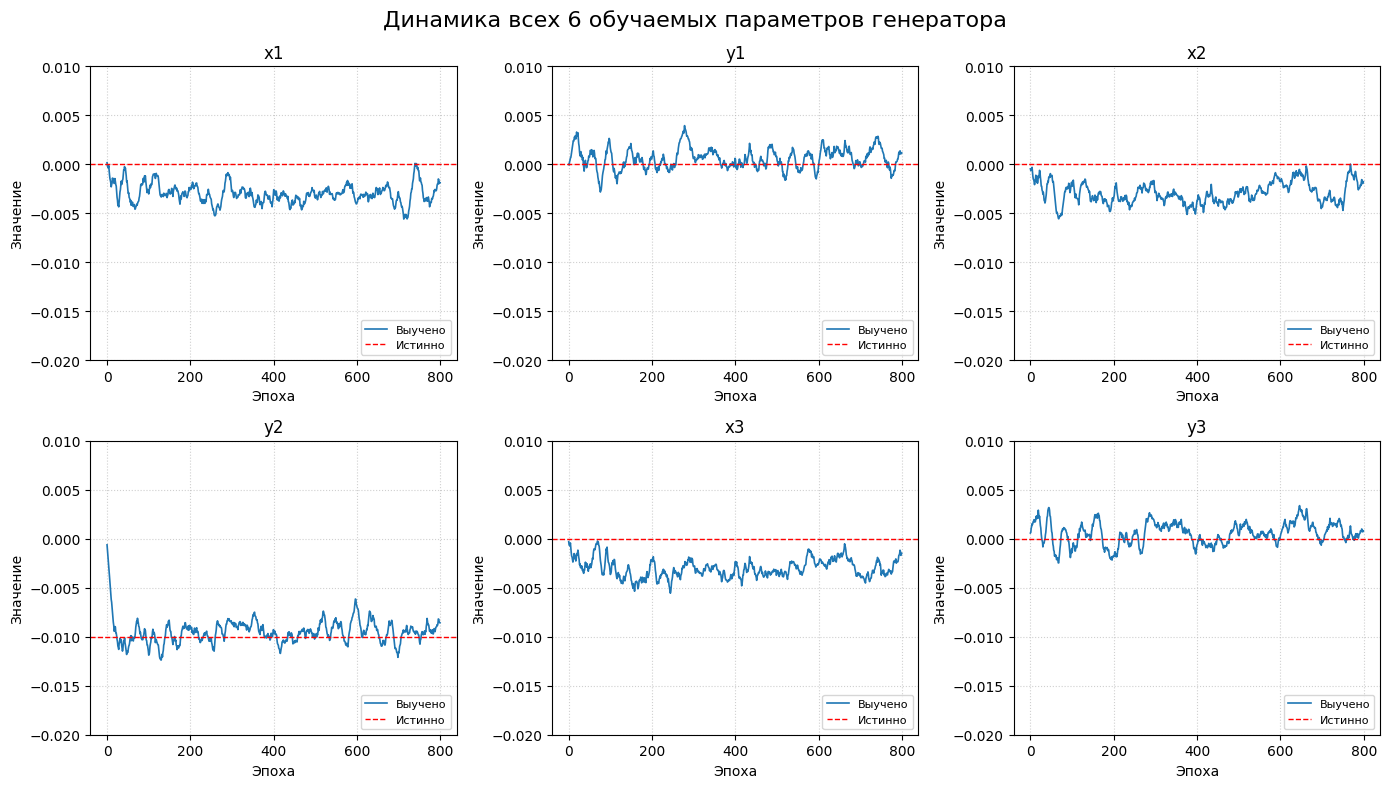

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

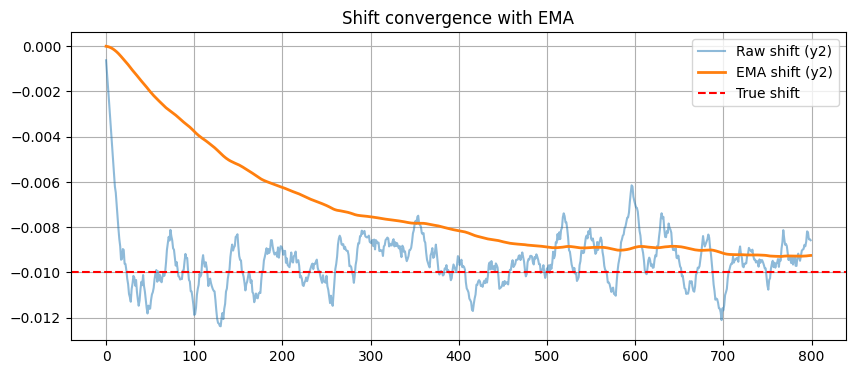

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

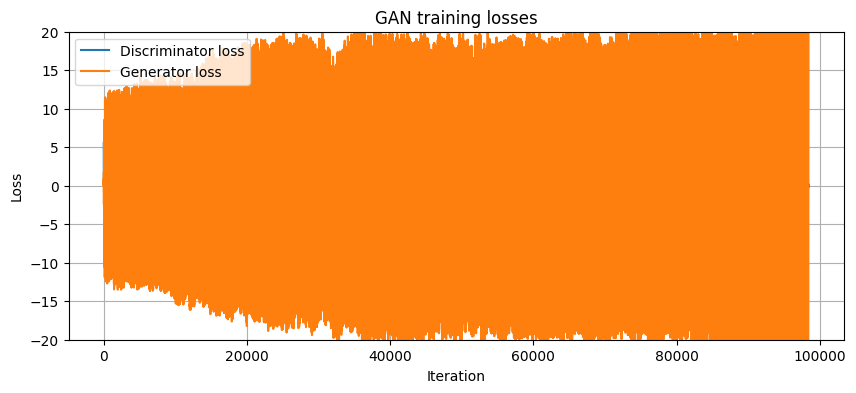

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#n_critic = 15

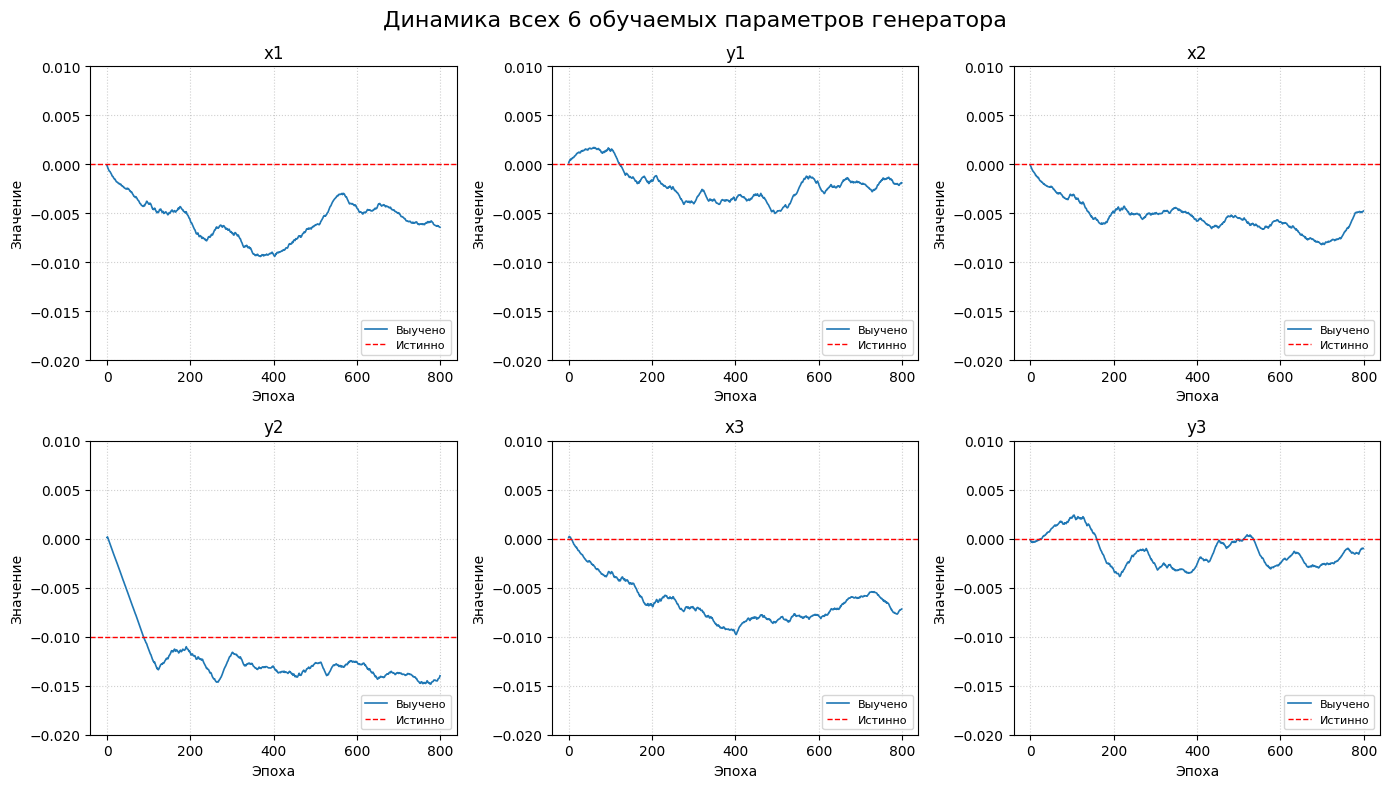

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

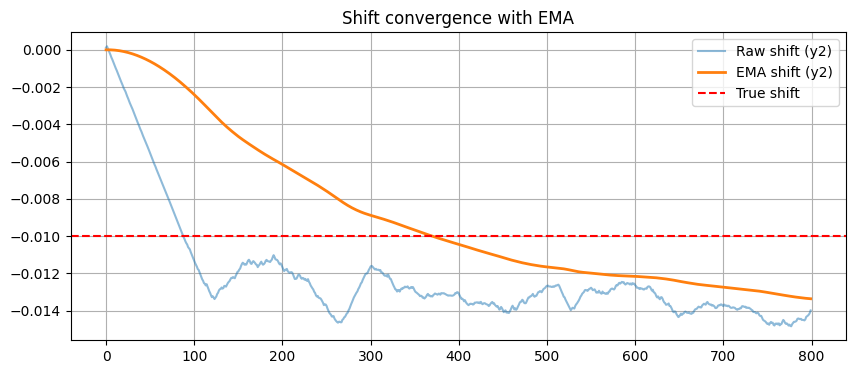

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

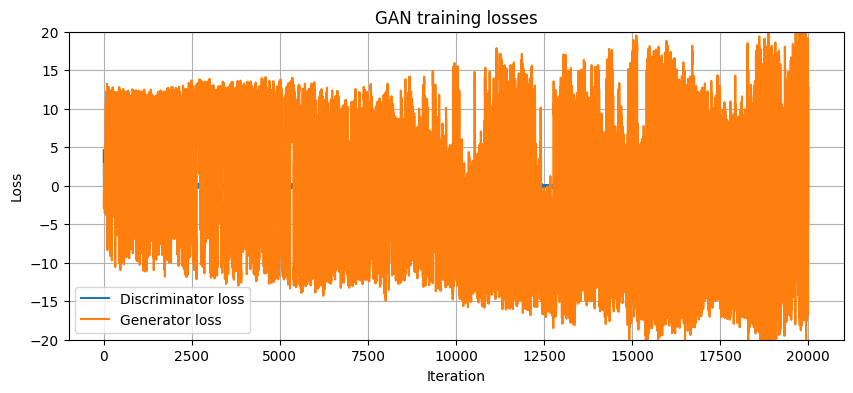

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#n_critic = 7

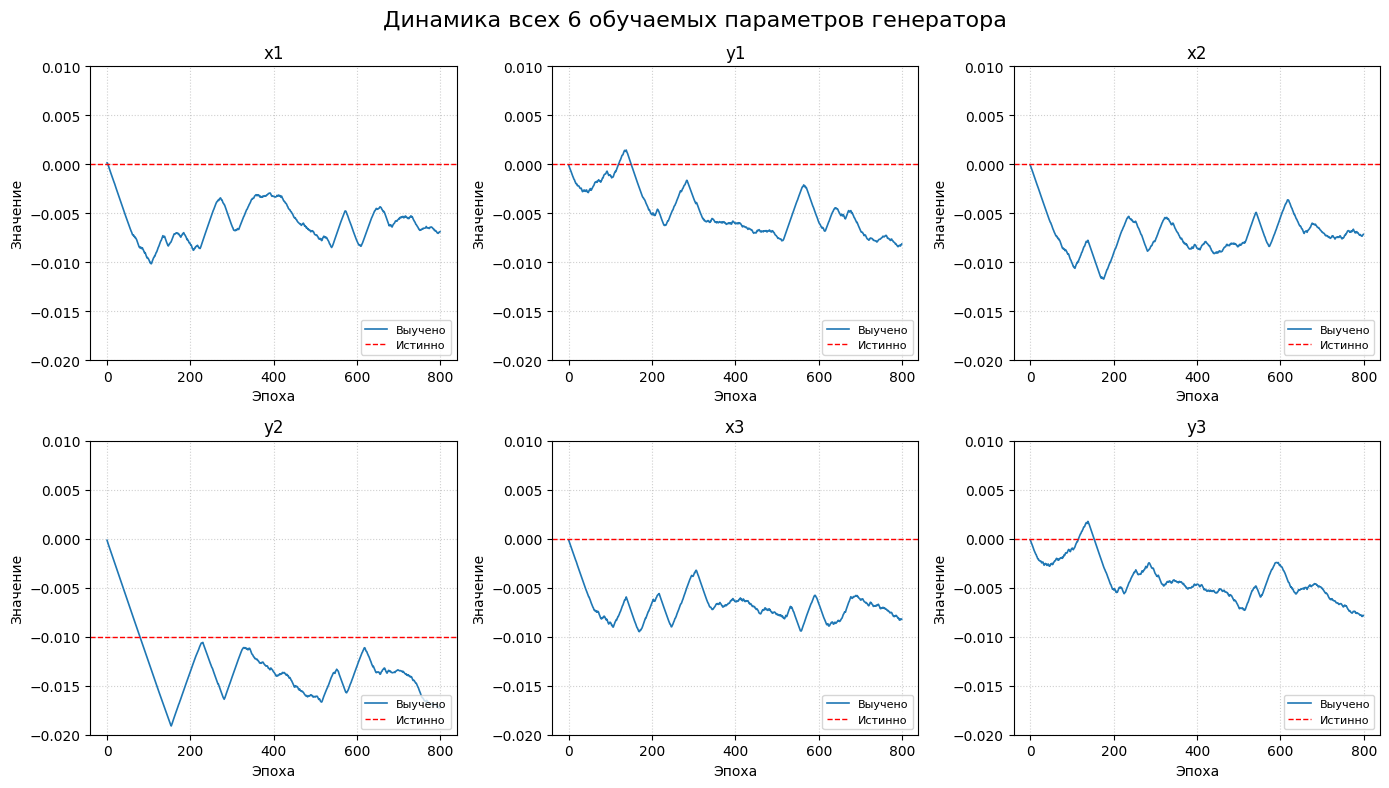

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

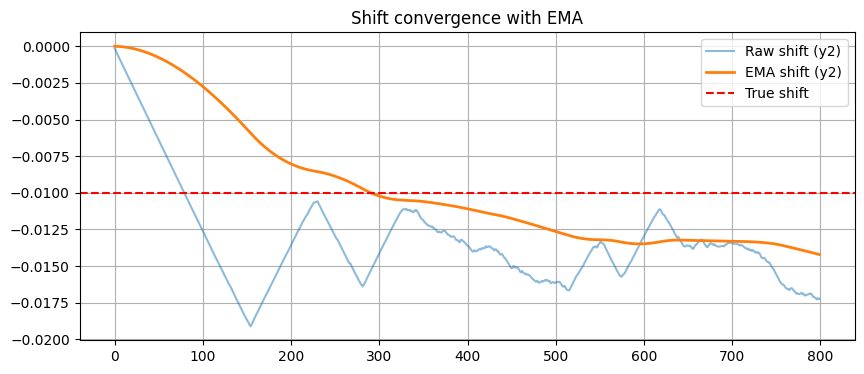

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

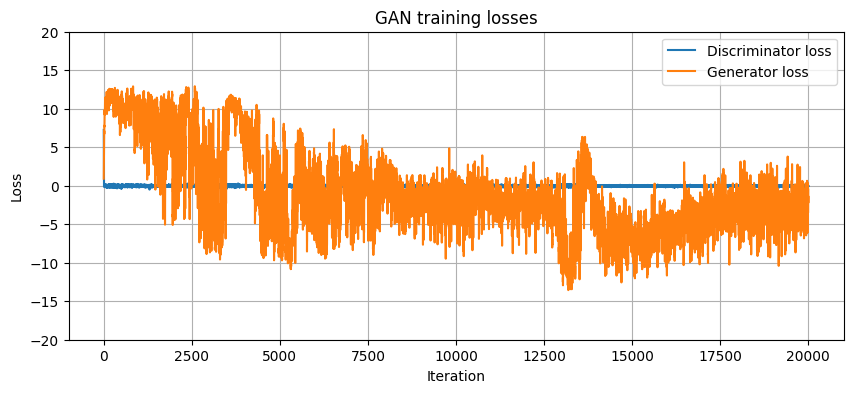

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#n_critic = 8

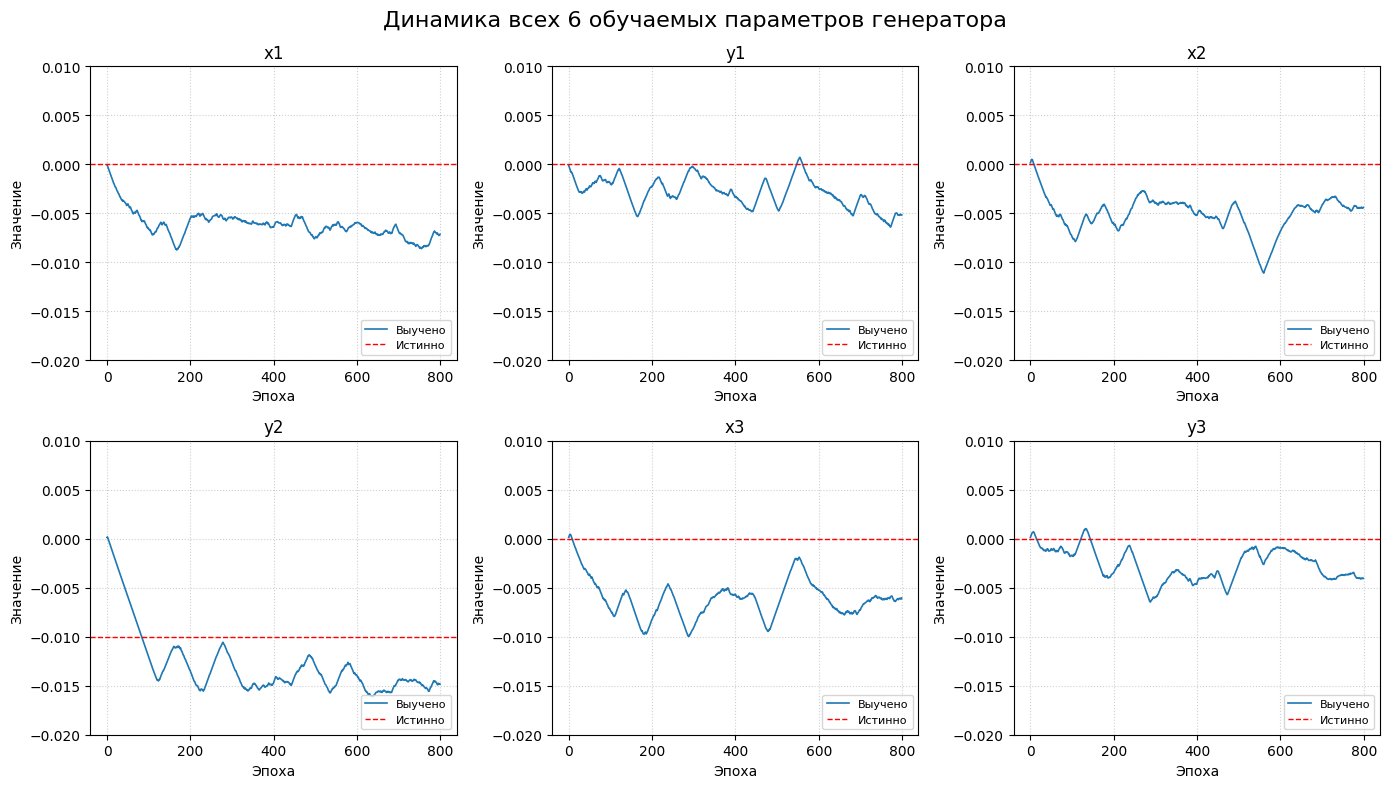

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

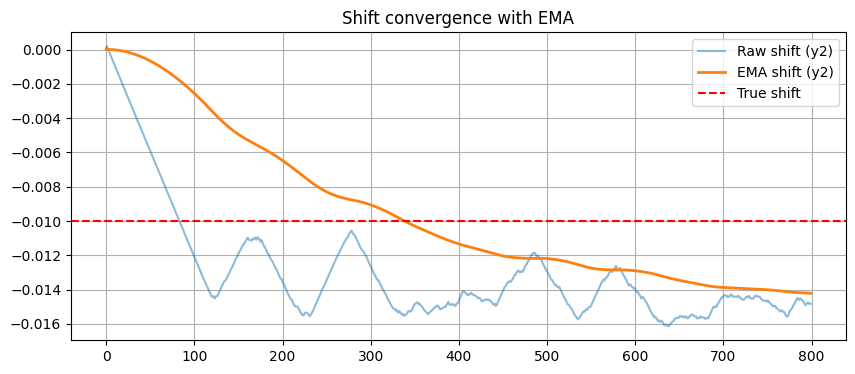

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

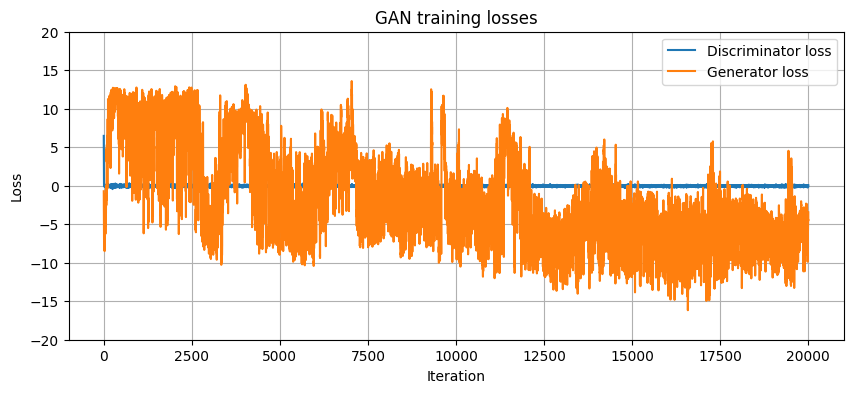

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#n_critic 5 -> 2

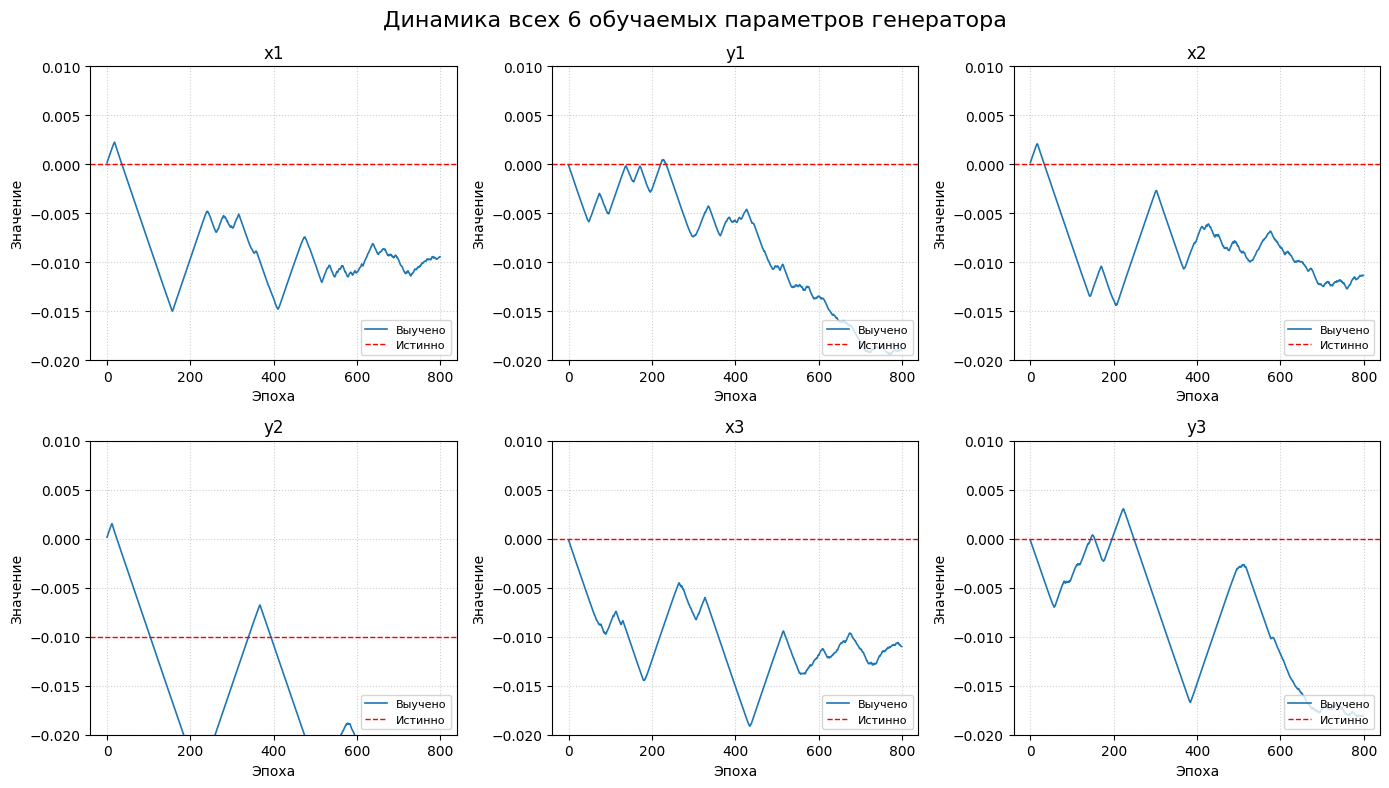

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

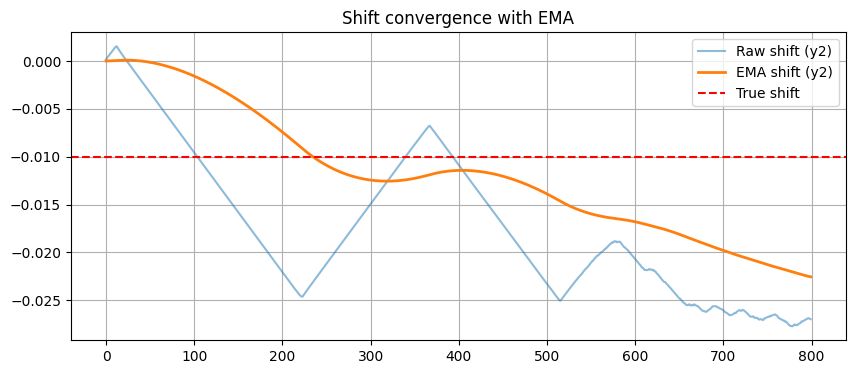

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

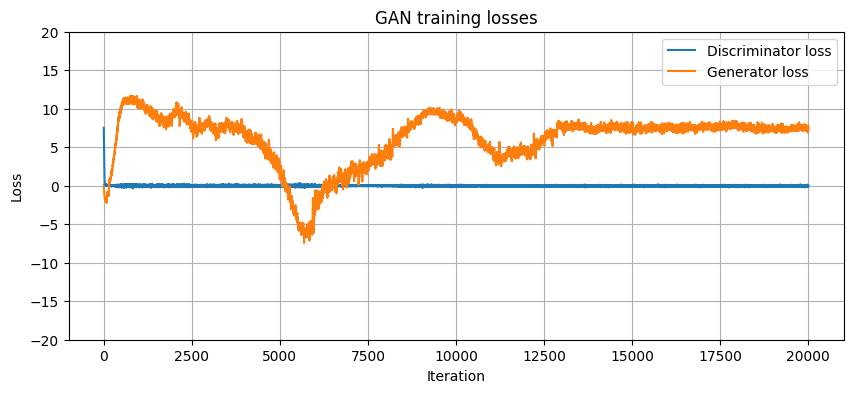

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#n_critic 10 -> 5


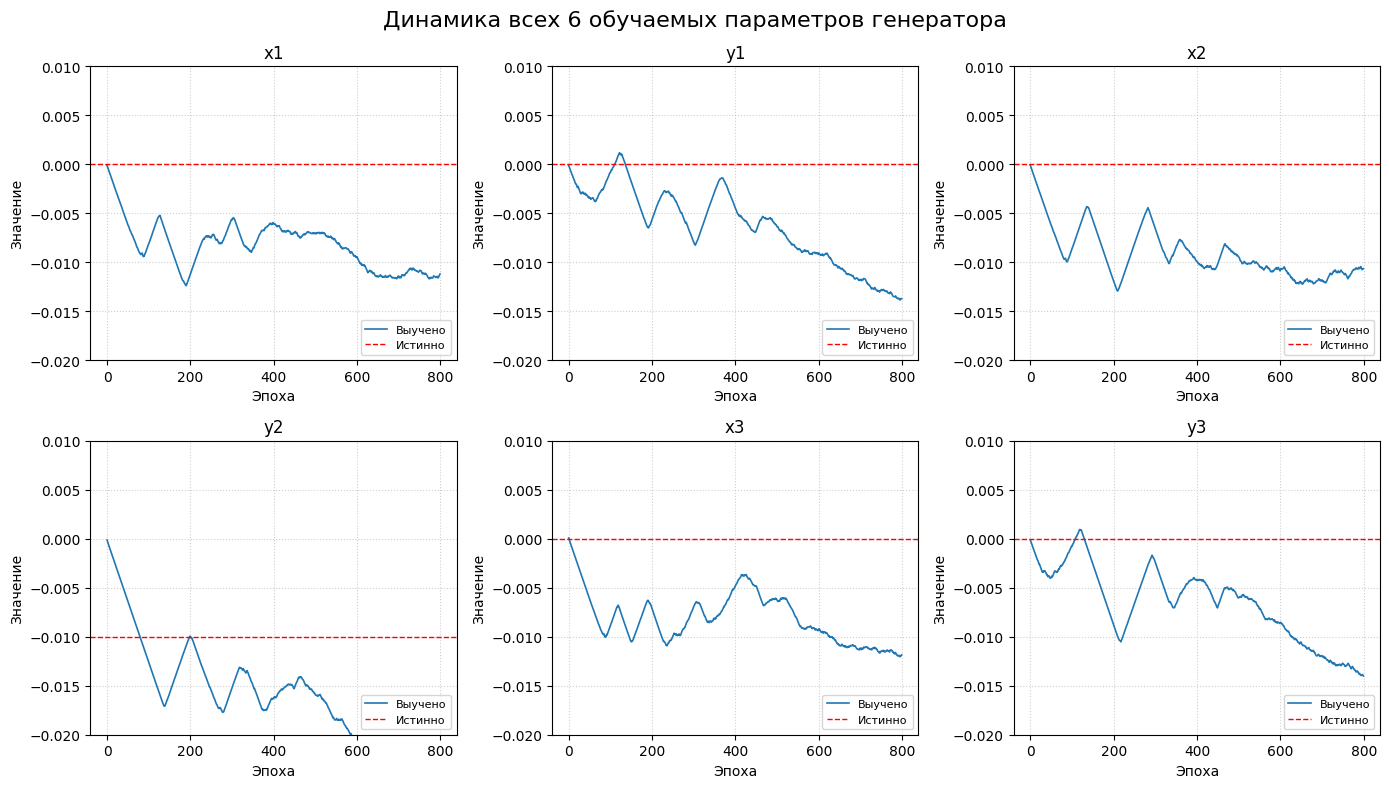

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

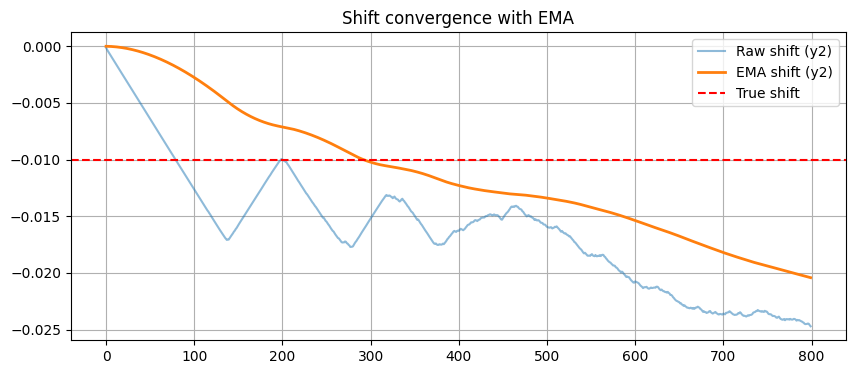

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

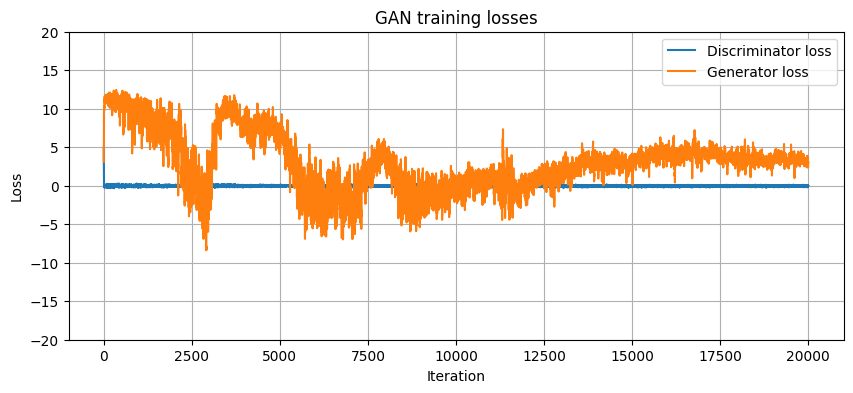

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#данные с разных распределений

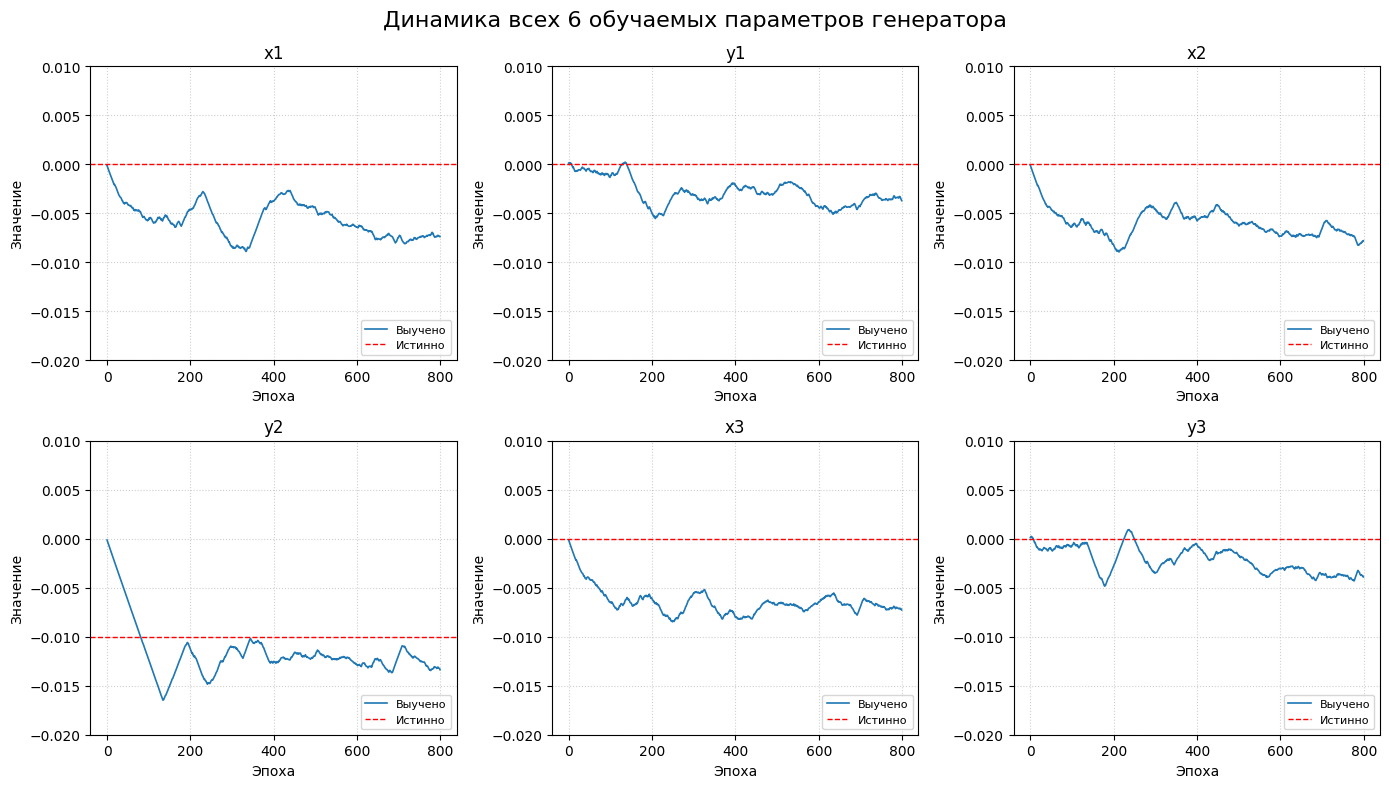

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

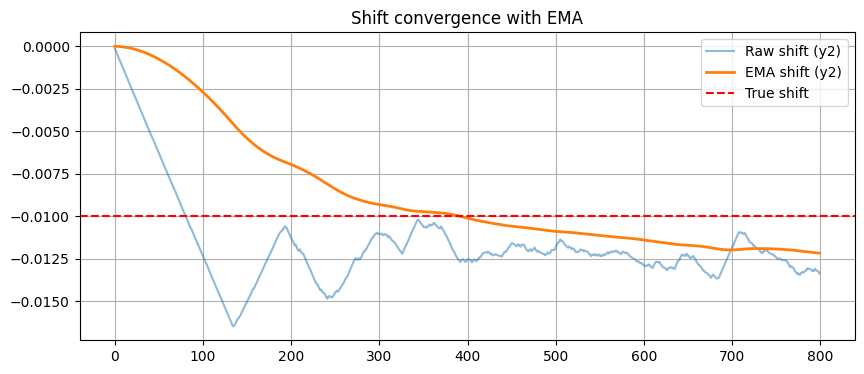

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

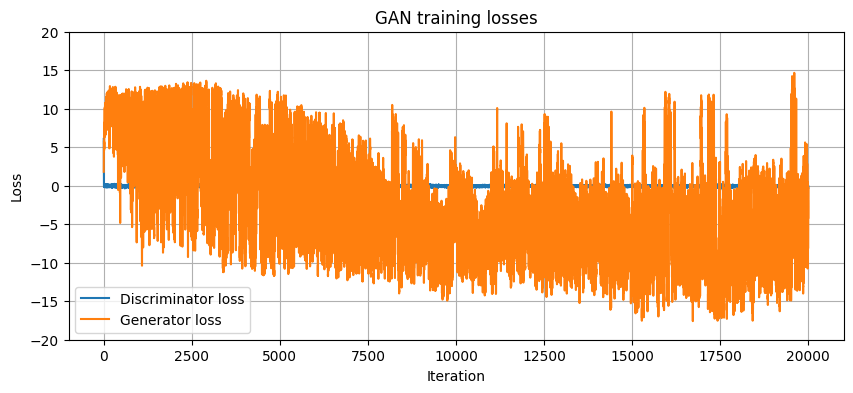

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()


#добавила ема (последний эксп с одинаковыми данными)

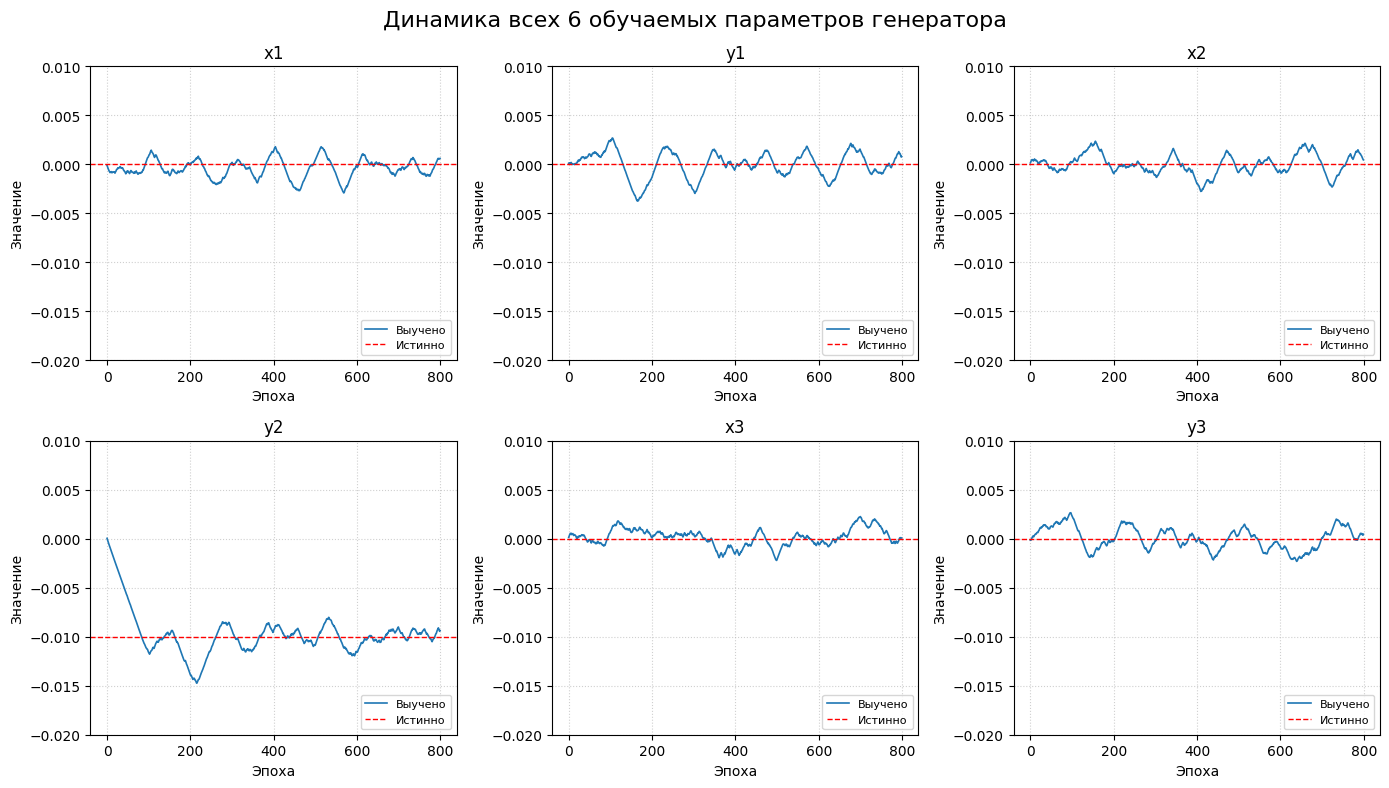

In [ ]:
shift_history = np.array(shift_history)

labels = ['x1', 'y1', 'x2', 'y2', 'x3', 'y3']
true_values = [0.0, 0.0, 0.0, -0.01, 0.0, 0.0]

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for i, (ax, label, true_val) in enumerate(zip(axs, labels, true_values)):
    ax.plot(shift_history[:, i], color='tab:blue', linewidth=1.2, label='Выучено')
    ax.axhline(y=true_val, color='red', linestyle='--', linewidth=1.0, label='Истинно')
    ax.set_ylim(-0.02, 0.01)
    ax.set_title(label)
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Значение')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Динамика всех 6 обучаемых параметров генератора', fontsize=16)
plt.tight_layout()
plt.show()

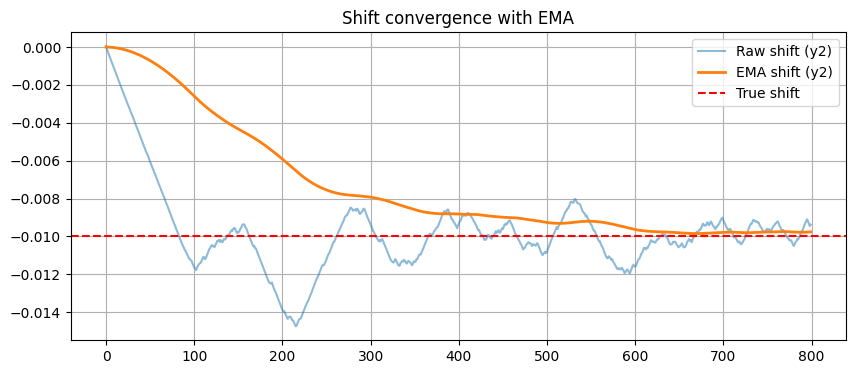

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(shift_history[:, 3], label="Raw shift (y2)", alpha=0.5)
plt.plot(ema_history, label="EMA shift (y2)", linewidth=2)

plt.axhline(y=-0.01, color='red', linestyle='--', label='True shift')

plt.legend()
plt.grid(True)
plt.title("Shift convergence with EMA")
plt.show()

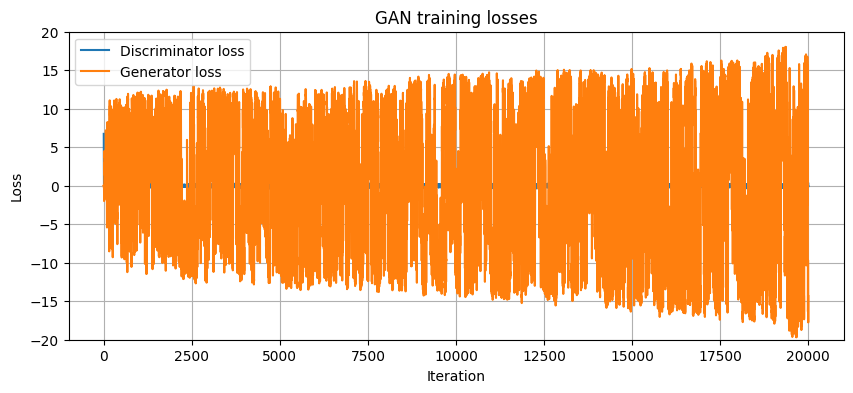

In [ ]:
plt.figure(figsize=(10, 4))
plt.ylim(-20, 20)
plt.plot(losses_D, label="Discriminator loss")
plt.plot(losses_G, label="Generator loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.title("GAN training losses")
plt.show()
